c:\ProgramData\miniforge3\lib\site-packages\matplotlib\colors.py:744: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


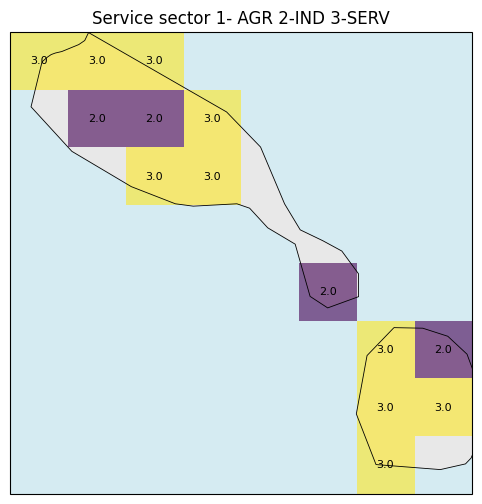

In [2]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

sn1 = 'RCP00 SSP3'
sn2 = 'RCP70 SSP3'
damage = 'GDP'

tif_file = f'C:/temp/ACMI/data GCCMI/data GCCMI/{sn2}/2030/bin/bin2030_KNA.01.tif'

# Load the .tif file
with rasterio.open(tif_file) as src:
    bounds = src.bounds  # Get the spatial extent
    data = src.read(1)   # Read the first band
    nodata = src.nodata if src.nodata is not None else np.nan
    masked_data = np.ma.masked_where(data == nodata, data)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([bounds.left, bounds.right, bounds.bottom, bounds.top], crs=ccrs.PlateCarree())
    
    # Add map features
    ax.add_feature(cfeature.BORDERS, linestyle='--', alpha=0.7)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
    
    # Plot the tif data with transparency for NoData values
    img = show(masked_data, transform=src.transform, cmap='viridis', ax=ax, alpha=0.6)
    
    # Annotate each grid cell with its value
    nrows, ncols = masked_data.shape
    for i in range(nrows):
        for j in range(ncols):
            if not masked_data.mask[i, j]:  # Only annotate non-masked cells
                value = masked_data[i, j]
                x, y = src.xy(i, j)
                ax.text(x, y, f'{value:.1f}', ha='center', va='center', fontsize=8, color='black')
    
    plt.title('Service sector 1- AGR 2-IND 3-SERV')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()



In [1]:
import rasterio
import numpy as np
import pandas as pd

# Scenario and damage information
 
damage = 'GDP'
country='KNA'
 

dfs=[]

for sn1 in ['RCP00 SSP3', 'RCP70 SSP3', 'RCP70 SSP3 noDIS', 'RCP70 SSP3 noDISREEF', 'RCP70 SSP3 noDISREEFSLR','RCP70 SSP3 noDISREEFSLRAGR','RCP00 SSP2', 'RCP45 SSP2','RCP45 SSP2 noDIS','RCP45 SSP2 noDISREEF','RCP45 SSP2 noDISREEFSLR','RCP45 SSP2 noDISREEFSLRAGR',]:	
    for year in ['2030', '2050']:
        # Load both TIF files for percentage change
        tif_file1 = f'C:/temp/ACMI/data GCCMI/data GCCMI/{sn1}/{year}/{damage}/{damage}_{country}.01.tif'
        grid_tif_file = f'C:/temp/ACMI/data GCCMI/data GCCMI/{sn1}/{year}/bin/bin{year}_{country}.01.tif'

        with rasterio.open(grid_tif_file) as src_grid:
            grid_bounds = src_grid.bounds
            grid_data = src_grid.read(1)
            grid_nodata = src_grid.nodata if src_grid.nodata is not None else np.nan
            landuse = np.ma.masked_where(grid_data == grid_nodata, grid_data)

        with rasterio.open(tif_file1) as elev_src:
            elevation = elev_src.read(1)  # Read as numpy array
            elev_meta = elev_src.meta
            elev_transform = elev_src.transform
            grid_nodata = elev_src.nodata if elev_src.nodata is not None else np.nan
            elevation = np.ma.masked_where(grid_data == grid_nodata, elevation)

        # Ensure both rasters have the same shape
        if elevation.shape != landuse.shape:
            raise ValueError("The rasters do not have the same dimensions!")

        # Flatten the arrays and remove NaN values
        valid_mask = (~np.isnan(elevation)) & (~np.isnan(landuse))
        landuse_flat = landuse[valid_mask]
        elevation_flat = elevation[valid_mask]

        # Create a DataFrame for grouping
        df = pd.DataFrame({"service": landuse_flat, "GDP": elevation_flat})
        df.dropna(inplace=True)
        df["service"] = df["service"].astype(int)	

        #df = df.groupby("service")["GDP"].mean().reset_index()
        df["senario"] = sn1
        df["year"] =year
        dfs.append(df)	
dfss = pd.concat(dfs)

dfss.replace({'service': {1: 'AGR', 2: 'IND',3:'SERV'}}, inplace=True)

In [8]:

def calculate_impact(df, scenario1, scenario2, year, service):
    df1 = df[(df['senario'] == scenario1) & (df['year'] == year) & (df['service'] == service)].groupby('service')['GDP'].mean().reset_index()
    df2 = df[(df['senario'] == scenario2) & (df['year'] == year) & (df['service'] == service)].groupby('service')['GDP'].mean().reset_index()
    
    if not df1.empty and not df2.empty:
        impact = 100 * (df2['GDP'].values[0] - df1['GDP'].values[0]) / df1['GDP'].values[0]
        return impact
    else:
        return None
    
def calculate_impact_national(df, scenario1, scenario2, year):
    df1 = df[(df['senario'] == scenario1) & (df['year'] == year) ]['GDP'].mean()
    df2 = df[(df['senario'] == scenario2) & (df['year'] == year) ]['GDP'].mean()
    
 
    impact = 100 * (df2 - df1) / df1
    return impact
 

scenarios = [
    ('RCP00 SSP3', 'RCP70 SSP3', 'Climate'),
    #('RCP70 SSP3', 'RCP70 SSP3 noDIS', 'Disaster'),
    ( 'RCP70 SSP3 noDIS','RCP70 SSP3', 'Disaster'),
    ('RCP70 SSP3 noDIS', 'RCP70 SSP3 noDISREEF', 'Reefs'),
    ('RCP70 SSP3 noDISREEF', 'RCP70 SSP3 noDISREEFSLR', 'Sea level rise'),
    ('RCP70 SSP3 noDISREEFSLR', 'RCP70 SSP3 noDISREEFSLRAGR', 'Agriculture'),
    ('RCP00 SSP3', 'RCP70 SSP3 noDISREEFSLRAGR', 'Temperature'),
    ('RCP00 SSP2', 'RCP45 SSP2', 'Climate'),
    #('RCP45 SSP2', 'RCP45 SSP2 noDIS', 'Disaster'),
    ('RCP45 SSP2 noDIS','RCP45 SSP2',  'Disaster'),
    ('RCP45 SSP2 noDIS', 'RCP45 SSP2 noDISREEF', 'Reefs'),
    ('RCP45 SSP2 noDISREEF', 'RCP45 SSP2 noDISREEFSLR', 'Sea level rise'),
    ('RCP45 SSP2 noDISREEFSLR', 'RCP45 SSP2 noDISREEFSLRAGR', 'Agriculture'),
    ('RCP00 SSP2', 'RCP45 SSP2 noDISREEFSLRAGR', 'Temperature')
]

years = ['2030', '2050']
services = ['IND', 'SERV']

impact_results = []

for year in years:
    for service in services:
        for scenario1, scenario2, variable in scenarios:
            impact = calculate_impact(dfss, scenario1, scenario2, year, service)
            if impact is not None:
                impact_results.append({
                    'year': year,
                    'Service_sector': service,
                    'Hazard': variable,
                    'ImpactonGDP': impact.round(2),
                    'climate_scenario': scenario2[0:10],
                })

impact_df = pd.DataFrame(impact_results)


impact_results = []

for year in years:
    for scenario1, scenario2, variable in scenarios:
        impact = calculate_impact_national(dfss, scenario1, scenario2, year)
        if impact is not None:
            impact_results.append({
                'Year': year,
                'Hazard': variable,
                'ImpactOnGDP': impact.round(2),
                'climate_scenario': scenario2[0:10],
            })

impact_df_national = pd.DataFrame(impact_results)
 

In [10]:
impact_df_national.to_csv('C:/temp/ACMI/data GCCMI/data GCCMI/impact_gdp_national.csv')
impact_df.to_csv('C:/temp/ACMI/data GCCMI/data GCCMI/impact_gdp_sector.csv')

In [9]:
impact_df.head()

,year,Service_sector,Hazard,ImpactonGDP,climate_scenario
0,2030,IND,Climate,-7.55,RCP70 SSP3
1,2030,IND,Disaster,-0.76,RCP70 SSP3
2,2030,IND,Reefs,-0.46,RCP70 SSP3
3,2030,IND,Sea level rise,-0.02,RCP70 SSP3
4,2030,IND,Agriculture,-0.01,RCP70 SSP3


In [115]:
impact_df_national.head()

,Year,Hazard,ImpactOnGDP,climate_scenario
0,2030,Climate,-6.23,RCP70 SSP3
1,2030,Reefs,-0.35,RCP70 SSP3
2,2030,Sea level rise,0.01,RCP70 SSP3
3,2030,Agriculture,-0.02,RCP70 SSP3
4,2030,Temperature,-5.45,RCP70 SSP3
